<a href="https://colab.research.google.com/github/prajwoldahal/AI-and-ML/blob/main/Worksheet4_Devnagari_FCN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 – Worksheet 4
## Fully Connected Neural Network for Devnagari Handwritten Digit Classification

**Tasks covered:**
1. Data Preparation
2. Build the FCN Model
3. Compile the Model
4. Train the Model
5. Evaluate the Model
6. Save and Load the Model
7. Make Predictions



In [1]:
import zipfile
import os


try:
    from google.colab import files
    print("Google Colab detected – please select your zip file in the dialog below.")
    uploaded = files.upload()
    ZIP_PATH = list(uploaded.keys())[0]
    print(f"Uploaded: {ZIP_PATH}")
except ImportError:

    ZIP_PATH = "Copy_of_devnagari_digit.zip"
    print(f"Local environment detected – using zip file: {ZIP_PATH}")

# ── Step 2: Extract the zip file ─────────────────────────────────────────────
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f"Zip file '{ZIP_PATH}' not found.\n"
        "Please upload it (Colab) or update ZIP_PATH to the correct local path."
    )

EXTRACT_DIR = "."
print(f"\nExtracting '{ZIP_PATH}' → '{EXTRACT_DIR}' …")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("Extraction complete!\n")


DATASET_ROOT = None
for entry in os.listdir(EXTRACT_DIR):
    candidate = os.path.join(EXTRACT_DIR, entry)
    if os.path.isdir(candidate):
        sub = os.listdir(candidate)
        if 'Train' in sub and 'Test' in sub:
            DATASET_ROOT = candidate
            break

if DATASET_ROOT is None:
    if os.path.isdir(os.path.join(EXTRACT_DIR, 'Train')):
        DATASET_ROOT = EXTRACT_DIR

if DATASET_ROOT:
    print(f"✓ Dataset root found : {DATASET_ROOT}")
    print(f"  Contents           : {os.listdir(DATASET_ROOT)}")
else:
    raise RuntimeError(
        "Could not find 'Train' and 'Test' folders after extraction.\n"
        "Please set DATASET_ROOT manually in the next cell."
    )

Google Colab detected – please select your zip file in the dialog below.


Saving Copy of devnagari digit.zip to Copy of devnagari digit.zip
Uploaded: Copy of devnagari digit.zip

Extracting 'Copy of devnagari digit.zip' → '.' …
Extraction complete!

✓ Dataset root found : ./DevanagariHandwrittenDigitDataset
  Contents           : ['Train', 'Test']


---
## Task 1 – Data Preparation
Load images with PIL, convert to NumPy arrays, normalise, and one-hot encode labels.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")

TensorFlow version : 2.19.0
Keras version      : 3.13.2


In [3]:


TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR  = os.path.join(DATASET_ROOT, "Test")

IMG_HEIGHT, IMG_WIDTH = 28, 28
NUM_CLASSES           = 10

for d in [TRAIN_DIR, TEST_DIR]:
    if os.path.isdir(d):
        print(f"✓ Found : {d}  ({len(os.listdir(d))} class folders)")
    else:
        print(f"✗ NOT found: {d}  ← check DATASET_ROOT")

✓ Found : ./DevanagariHandwrittenDigitDataset/Train  (10 class folders)
✓ Found : ./DevanagariHandwrittenDigitDataset/Test  (10 class folders)


In [4]:
def load_images_from_folder(folder: str):
    """
    Walk through class sub-folders inside `folder`, load each PNG image
    with PIL, convert to grayscale, resize to (IMG_HEIGHT x IMG_WIDTH),
    and normalise pixel values to [0, 1].

    Returns
    -------
    images : np.ndarray  shape (N, IMG_HEIGHT, IMG_WIDTH, 1)
    labels : np.ndarray  shape (N,)  integer class indices
    """
    images, labels = [], []

    class_names = sorted(os.listdir(folder))          # digit_0 … digit_9
    class_map   = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")             # grayscale
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))           # 28 × 28
            img_array = np.array(img, dtype=np.float32) / 255.0 # normalise
            images.append(img_array)
            labels.append(label)

    images = np.array(images).reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
    labels = np.array(labels)
    return images, labels

In [5]:
print("Loading training data …")
x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)

print("Loading test data …")
x_test, y_test_raw = load_images_from_folder(TEST_DIR)

# One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"\nTraining set : {x_train_raw.shape}  →  labels {y_train.shape}")
print(f"Test set     : {x_test.shape}  →  labels {y_test.shape}")

Loading training data …
Loading test data …

Training set : (17000, 28, 28, 1)  →  labels (17000, 10)
Test set     : (3000, 28, 28, 1)  →  labels (3000, 10)


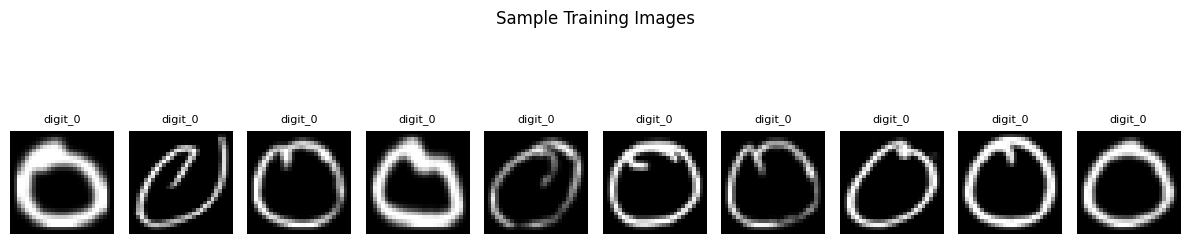

In [6]:
# ── Visualise 10 sample training images ─────────────────────────────────────
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_raw[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    plt.title(f"digit_{y_train_raw[i]}", fontsize=8)
    plt.axis('off')
plt.suptitle("Sample Training Images", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

---
## Task 2 – Build the FCN Model
Sequential model with 3 hidden layers (64 → 128 → 256 neurons, sigmoid) and a 10-unit softmax output.

In [7]:
def build_fcn_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1), num_classes=NUM_CLASSES):
    """Build and return the Fully Connected Network."""
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),

        # Flatten 28×28×1  →  784
        keras.layers.Flatten(),

        # Hidden layer 1
        keras.layers.Dense(64,  activation='sigmoid', name='hidden_1'),

        # Hidden layer 2
        keras.layers.Dense(128, activation='sigmoid', name='hidden_2'),

        # Hidden layer 3
        keras.layers.Dense(256, activation='sigmoid', name='hidden_3'),

        # Output layer  –  10 classes
        keras.layers.Dense(num_classes, activation='softmax', name='output'),
    ], name='FCN_Devnagari')

    return model


model = build_fcn_model()
model.summary()

Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3 – Compile the Model

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',   # labels are one-hot encoded
    metrics=['accuracy']
)

print("Model compiled successfully.")
print(f"  Optimizer : {model.optimizer.get_config()['name']}")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metrics   : accuracy")

Model compiled successfully.
  Optimizer : adam
  Loss      : categorical_crossentropy
  Metrics   : accuracy


---
## Task 4 – Train the Model
* Batch size = 128, epochs = 20
* 20 % validation split
* Callbacks: `ModelCheckpoint` (saves best model) and `EarlyStopping` (patience = 5)

In [9]:
BATCH_SIZE      = 128
EPOCHS          = 20
CHECKPOINT_PATH = 'best_devnagari_model.keras'

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

history = model.fit(
    x_train_raw,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2784 - loss: 1.9569
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4823 - loss: 1.5798 - val_accuracy: 0.0000e+00 - val_loss: 7.8500
Epoch 2/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8187 - loss: 0.6192
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8524 - loss: 0.4912 - val_accuracy: 0.0000e+00 - val_loss: 8.9718
Epoch 3/20
 98/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9180 - loss: 0.2943
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9280 - loss: 0.2581 - val_accuracy: 0.0000e+00 - val_loss: 9.5680
Epoch 4/20
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9467 - loss: 0.1907
Epoch 4: val_accuracy did not imp

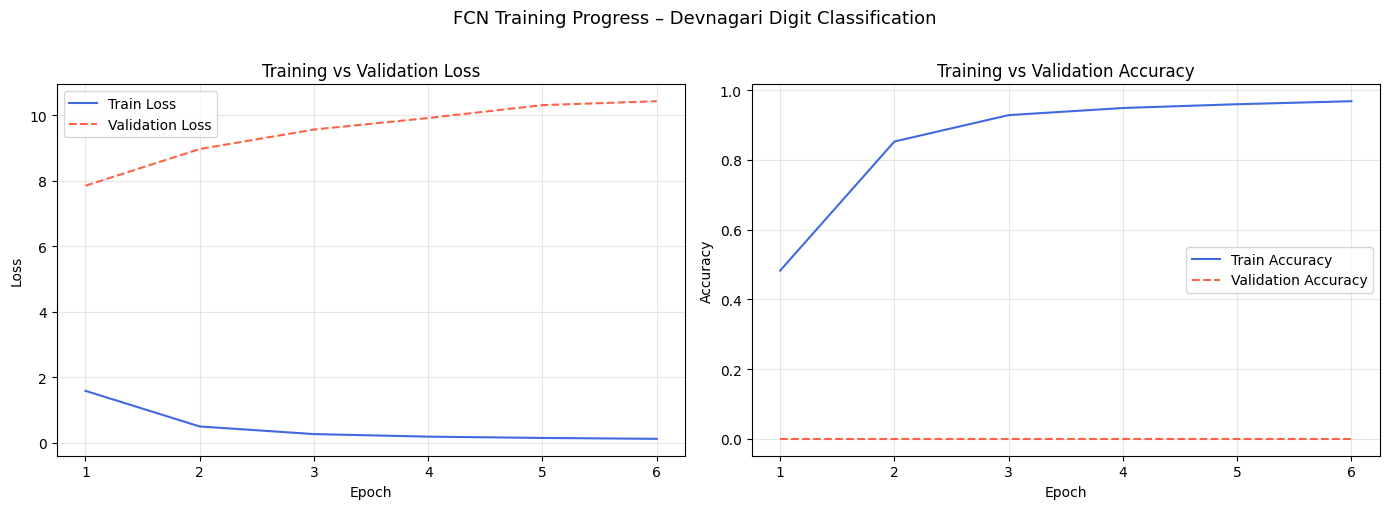

Training curves saved to training_curves.png


In [10]:
# ── Plot training curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history.history['loss']) + 1)

# Loss
axes[0].plot(epochs_ran, history.history['loss'],     label='Train Loss',      color='royalblue')
axes[0].plot(epochs_ran, history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history.history['accuracy'],     label='Train Accuracy',      color='royalblue')
axes[1].plot(epochs_ran, history.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('FCN Training Progress – Devnagari Digit Classification', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved to training_curves.png")

---
## Task 5 – Evaluate the Model on the Test Set

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc * 100:.2f} %")
print(f"{'='*40}")

94/94 - 0s - 2ms/step - accuracy: 0.6033 - loss: 2.2244

  Test Loss     : 2.2244
  Test Accuracy : 60.33 %


---
## Task 6 – Save and Load the Model

In [12]:
# ── Save ─────────────────────────────────────────────────────────────────────
SAVE_PATH = 'devnagari_fcn_model.h5'
model.save(SAVE_PATH)
print(f"Model saved  →  {SAVE_PATH}")

Model saved  →  devnagari_fcn_model.h5


In [13]:
# ── Load ─────────────────────────────────────────────────────────────────────
loaded_model = tf.keras.models.load_model(SAVE_PATH)
print(f"Model loaded from  →  {SAVE_PATH}")

# Re-evaluate with the loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"\nLoaded model – Test Loss     : {loaded_loss:.4f}")
print(f"Loaded model – Test Accuracy : {loaded_acc * 100:.2f} %")

Model loaded from  →  devnagari_fcn_model.h5

Loaded model – Test Loss     : 2.2244
Loaded model – Test Accuracy : 60.33 %


---
## Task 7 – Make Predictions

In [14]:
# Run predictions on the entire test set
predictions      = loaded_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)   # class with highest probability
true_labels      = np.argmax(y_test, axis=1)

# Quick sanity check
print(f"Predicted label for image[0] : {predicted_labels[0]}")
print(f"True label      for image[0] : {true_labels[0]}")

Predicted label for image[0] : 0
True label      for image[0] : 0


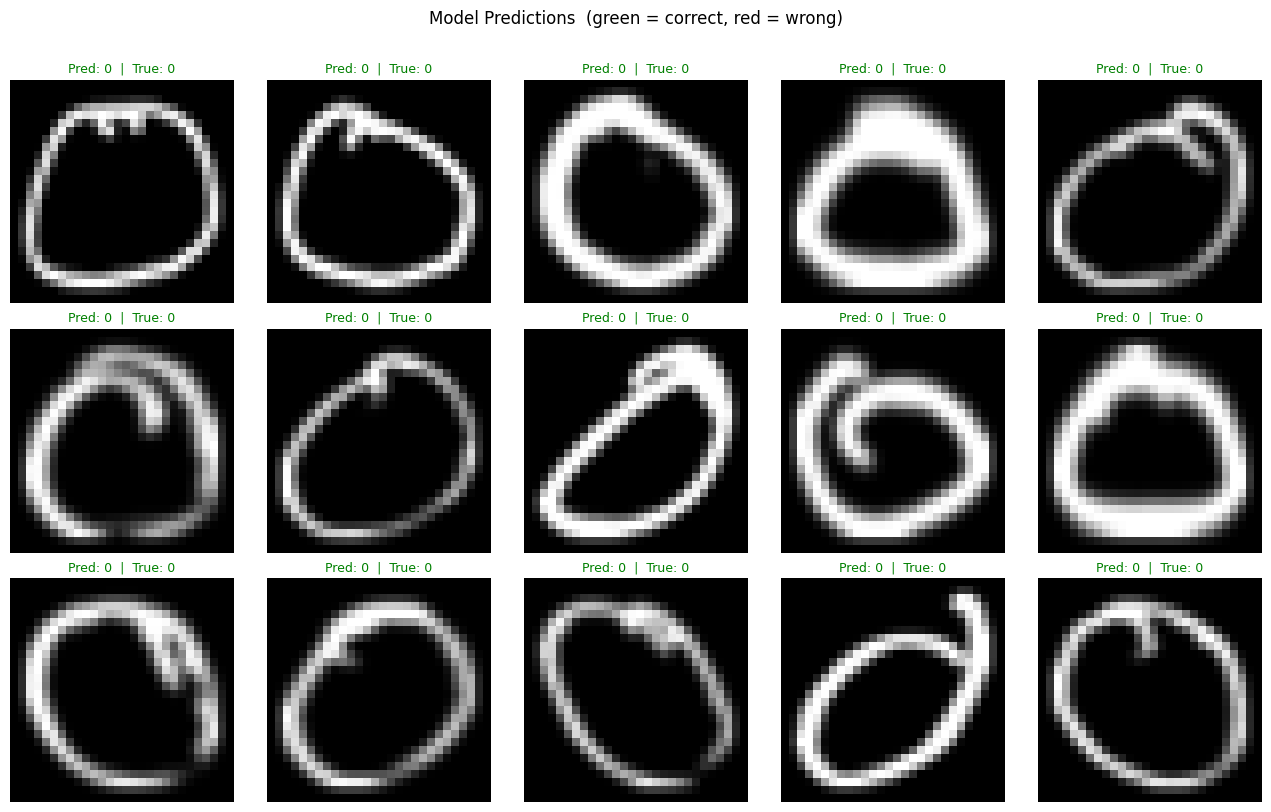

Prediction grid saved to predictions_sample.png


In [15]:
# ── Visualise 15 predictions ─────────────────────────────────────────────────
n_show = 15
fig, axes = plt.subplots(3, 5, figsize=(13, 8))

for idx, ax in enumerate(axes.flat):
    ax.imshow(x_test[idx].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    pred  = predicted_labels[idx]
    true  = true_labels[idx]
    color = 'green' if pred == true else 'red'
    ax.set_title(f"Pred: {pred}  |  True: {true}", color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Model Predictions  (green = correct, red = wrong)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('predictions_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print("Prediction grid saved to predictions_sample.png")

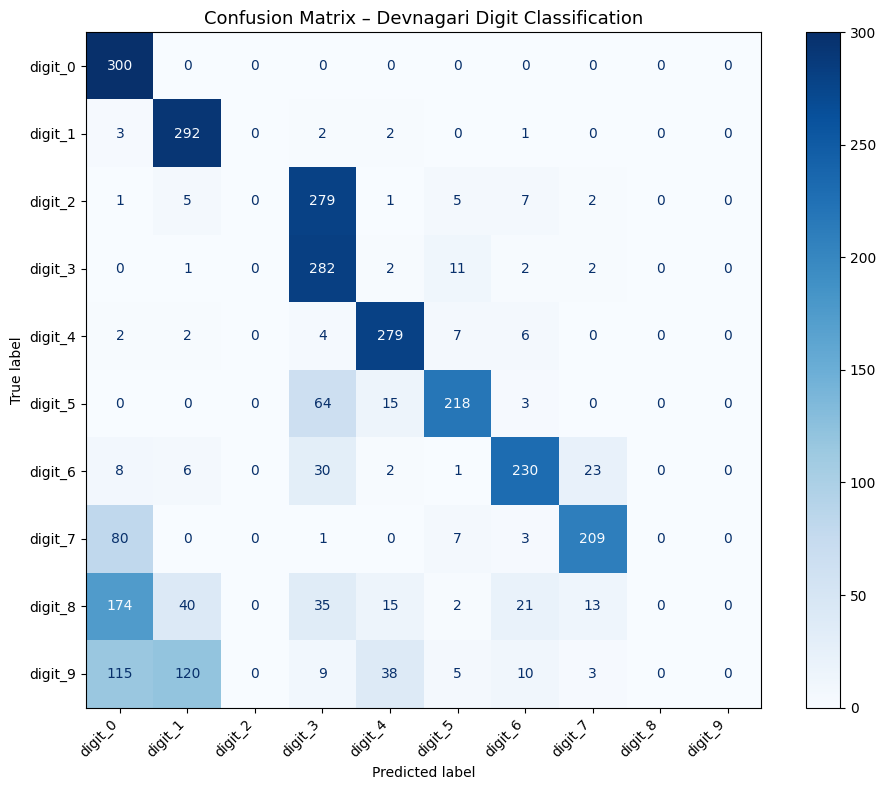


Classification Report:
              precision    recall  f1-score   support

     digit_0       0.44      1.00      0.61       300
     digit_1       0.63      0.97      0.76       300
     digit_2       0.00      0.00      0.00       300
     digit_3       0.40      0.94      0.56       300
     digit_4       0.79      0.93      0.85       300
     digit_5       0.85      0.73      0.78       300
     digit_6       0.81      0.77      0.79       300
     digit_7       0.83      0.70      0.76       300
     digit_8       0.00      0.00      0.00       300
     digit_9       0.00      0.00      0.00       300

    accuracy                           0.60      3000
   macro avg       0.47      0.60      0.51      3000
weighted avg       0.47      0.60      0.51      3000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[f"digit_{i}" for i in range(NUM_CLASSES)])
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title('Confusion Matrix – Devnagari Digit Classification', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels,
                            target_names=[f"digit_{i}" for i in range(NUM_CLASSES)]))

   Summary
-  Data loaded with PIL, normalised, one-hot encoded
-  FCN model built with the required architecture
-  Training & validation curves plotted
-  Test accuracy and loss reported
-  Model saved and reloaded
-  Predictions made and visualised with a confusion matrix